# Decide \> Simulate

Use Monte Carlo simulation to understand risk before making a decision.

Simulation is useful when a decision depends on uncertain inputs and
formulas that are too messy for a simple hand calculation. The workflow
is:

1.  Define uncertain inputs and constants.
2.  Define formulas that translate inputs into outcomes.
3.  Simulate many draws.
4.  Summarize the distribution of outcomes, not just the average.
5.  Repeat the simulation over many periods when the decision depends on
    a horizon such as a year.

Radiant presents this under *Model \> Decide \> Simulate*. In Python the
corresponding API is `rsm.decide.simulate` and
`rsm.decide.repeat_simulate`.

In [1]:
import polars as pl
import pyrsm as rsm
import matplotlib.pyplot as plt

In [2]:
## setup pyrsm for autoreload
%reload_ext autoreload
%autoreload 2
%aimport pyrsm

## Example 1: Daily Profit Simulation

This example mirrors the structure in the Radiant documentation.
Variable cost and fixed cost are constants. `E` is a normally
distributed demand shock. `price` is a discrete random variable that is
either 6 or 8, with probabilities 0.3 and 0.7. The formulas create
demand, profit, and an indicator for whether profit is below 100.

In [3]:
daily_spec = rsm.decide.SimulationSpec(
    name="daily profit",
    runs=1000,
    seed=1234,
    variables=[
        rsm.decide.Variable(name="var_cost", kind="constant", value=5),
        rsm.decide.Variable(name="fixed_cost", kind="constant", value=1000),
        rsm.decide.Variable(name="E", kind="normal", mean=0, sd=100),
        rsm.decide.Variable(
            name="price",
            kind="discrete",
            values=[6, 8],
            probs=[0.3, 0.7],
        ),
    ],
    formulas=[
        rsm.decide.Formula(name="demand", expr="max(0, 1000 - 50 * price + E)"),
        rsm.decide.Formula(name="profit", expr="demand * (price - var_cost) - fixed_cost"),
        rsm.decide.Formula(name="profit_small", expr="profit < 100"),
    ],
)

daily = rsm.decide.simulate(daily_spec)
daily.has_errors, [d.to_dict() for d in daily.diagnostics]

(False, [])

In [4]:
daily.data.head()

### Reading the Summary

The mean profit is the expected daily profit under the assumed
distributions. The standard deviation and quantiles tell us how much
daily profit varies. The logical variable `profit_small` is stored as
`True` or `False`; its mean is the simulated probability that profit is
below 100.

In [5]:
pl.DataFrame(daily.summary_rows)

In [6]:
daily.data.select(
    pl.col("profit").mean().alias("expected_profit"),
    pl.col("profit").quantile(0.05).alias("profit_p5"),
    pl.col("profit_small").cast(pl.Float64).mean().alias("prob_profit_below_100"),
)

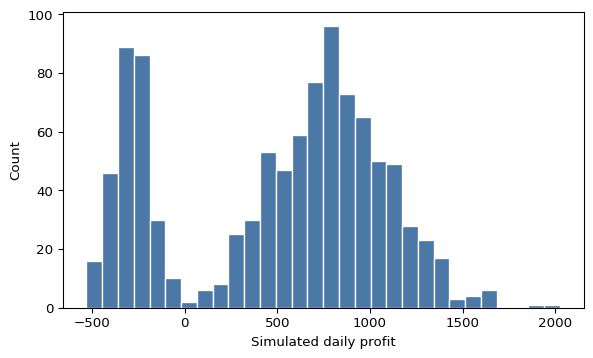

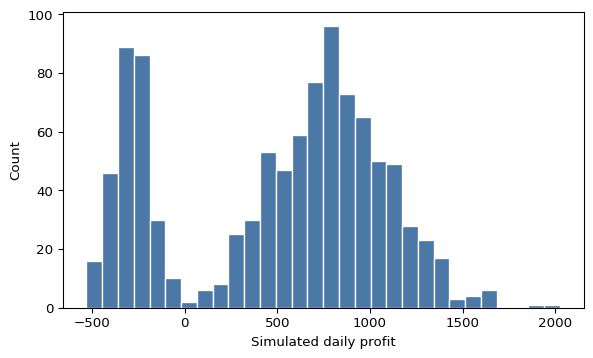

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(daily.data["profit"].to_numpy(), bins=30, color="#4C78A8", edgecolor="white")
ax.set_xlabel("Simulated daily profit")
ax.set_ylabel("Count")
fig

## Formula Tips

Simulation formulas are evaluated with a restricted expression grammar.
That keeps examples reproducible and avoids arbitrary Python execution.
Useful functions include:

-   `ifelse(condition, value_if_true, value_if_false)`
-   `min(x, y, ...)` and `max(x, y, ...)`
-   `abs(x)`, `sqrt(x)`, `log(x)`, and `exp(x)`
-   comparisons such as `profit < 100`, which produce logical variables

The generated code can be used to reproduce the simulation outside the
notebook.

In [8]:
print(daily.python_code)

import numpy as np
import polars as pl

rng = np.random.default_rng(1234)
runs = 1000

data = (
    pl.DataFrame({
        'var_cost': np.full(runs, 5.0),
        'fixed_cost': np.full(runs, 1000.0),
        'E': rng.normal(0, 100, runs),
        'price': rng.choice([6, 8], runs, p=[0.3, 0.7]),
    })
    .with_columns(demand=pl.max_horizontal(0, ((1000 - (50 * pl.col('price'))) + pl.col('E'))))
    .with_columns(profit=((pl.col('demand') * (pl.col('price') - pl.col('var_cost'))) - pl.col('fixed_cost')))
    .with_columns(profit_small=(pl.col('profit') < 100))
)

print(data.describe())

## Example 2: Annual Profit from Repeated Daily Simulations

Daily risk can look large even when annual risk is small because good
and bad days offset each other. To study a 365-day horizon, set
`runs=365` for the base specification and use
`repeat_simulate(..., reps=1000)` to create 1,000 simulated years.

The `resample` argument identifies variables that should get new random
draws in every simulated year. Here `E` and `price` vary from day to day
and year to year. Constants such as variable cost and fixed cost are
reused.

In [9]:
annual_spec = rsm.decide.SimulationSpec(
    name="annual profit",
    runs=365,
    seed=1234,
    variables=daily_spec.variables,
    formulas=daily_spec.formulas,
)

annual = rsm.decide.repeat_simulate(
    annual_spec,
    reps=1000,
    agg="sum",
    resample=["E", "price"],
    repeat_formulas=[
        rsm.decide.Formula(
            name="annual_below_target",
            expr="profit_sum < 36500",
        )
    ],
)
annual.has_errors, [d.to_dict() for d in annual.diagnostics]

(False, [])

In [10]:
annual.data.head()

In [11]:
pl.DataFrame(annual.summary_rows)

In [12]:
annual.data.select(
    pl.col("profit_sum").mean().alias("expected_annual_profit"),
    pl.col("profit_sum").quantile(0.05).alias("annual_profit_p5"),
    pl.col("annual_below_target").cast(pl.Float64).mean().alias("prob_below_36500"),
)

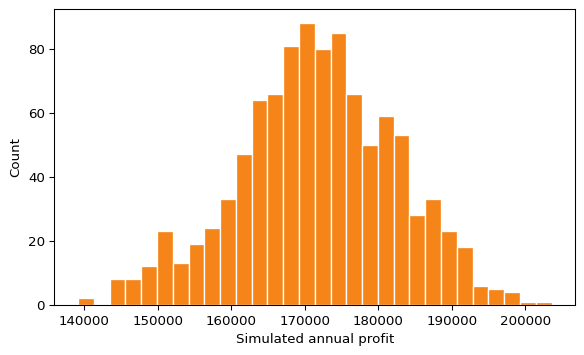

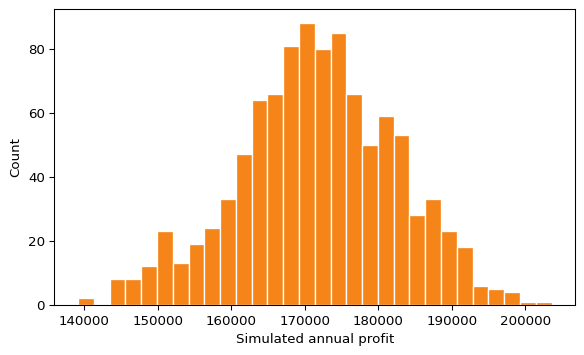

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(annual.data["profit_sum"].to_numpy(), bins=30, color="#F58518", edgecolor="white")
ax.set_xlabel("Simulated annual profit")
ax.set_ylabel("Count")
fig

The annual distribution is much tighter relative to its mean than the
daily distribution. This is the main teaching point: a simulation should
match the decision horizon.

## Supported Variable Kinds

`rsm.decide.Variable` currently supports:

-   `constant`
-   `normal`
-   `uniform`
-   `binomial`
-   `poisson`
-   `lognormal`
-   `discrete`
-   `sequence`

Use `sequence` when you want to evaluate a range of deterministic
inputs, such as a set of candidate prices. Use `repeat_simulate` when
the decision depends on accumulated outcomes across many repeated
periods.